# Chance

In [16]:
from datascience import *
%matplotlib inline

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np
import warnings

## Simulation Review

In [17]:
coin = make_array('heads', 'tails')

In [18]:
np.random.choice(coin)

'tails'

In [19]:
tosses = np.random.choice(coin, 10)
tosses

array(['tails', 'tails', 'tails', 'tails', 'heads', 'tails', 'tails',
       'tails', 'tails', 'heads'],
      dtype='<U5')

In [20]:
sum(tosses == 'heads')

2

In [21]:
sum(np.random.choice(coin, 10) == 'heads')

5

In [22]:
# Simulate one outcome based on 100 tosses

def heads_in_100_tosses():
    return sum(np.random.choice(coin, 100) == 'heads')

In [23]:
# Decide how many times you want to repeat the experiment

num_simulations = 10000

In [24]:
# Simulate that many outcomes

outcomes = make_array()

for i in np.arange(num_simulations):
    outcomes = np.append(outcomes, heads_in_100_tosses())
    
outcomes

array([ 52.,  57.,  49., ...,  50.,  59.,  46.])

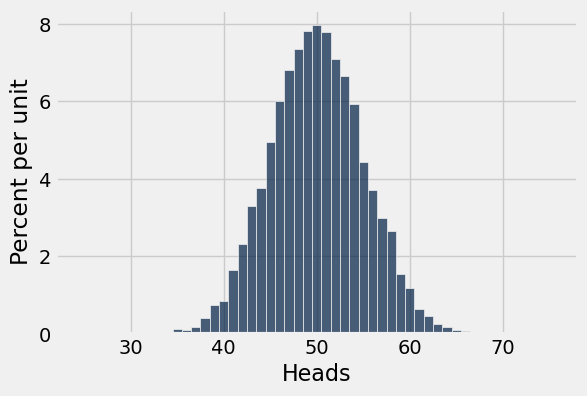

In [25]:
heads = Table().with_column('Heads', outcomes)
heads.hist(bins = np.arange(24.5, 76.5))

## Chance #

### Probability Question

3 cards: A, K, Q

Draw two cards at random without replacement.

What is the chance of a Queen followed by a King?

First Solution:


Alternative Solution:


### Another Question

Same setting as above.

What is the chance that one of the cards drawn is the King and the other is the Queen?

First Solution:


Alternative Solution:


### Complement Rule

Done on slide.

### The Monty Hall Problem ###

In [26]:
goats = make_array('first goat', 'second goat')
doors = make_array('car', 'first goat', 'second goat')
doors

array(['car', 'first goat', 'second goat'],
      dtype='<U11')

In [27]:
def other_goat(x):
    if x == 'first goat':
        return 'second goat'
    elif x == 'second goat':
        return 'first goat'

In [28]:
make_array(other_goat('first goat'), other_goat('second goat'))

array(['second goat', 'first goat'],
      dtype='<U11')

In [29]:
def monty_hall():
    """Return 
    [contestant's guess, what Monty reveals, what remains behind the other door]"""
    
    contestant_choice = np.random.choice(doors)
    
    if contestant_choice == 'first goat':
        monty_choice = 'second goat'
        remaining_choice = 'car'
    
    if contestant_choice == 'second goat':
        monty_choice = 'first goat'
        remaining_choice = 'car'
    
    if contestant_choice == 'car':
        monty_choice = np.random.choice(goats)
        remaining_choice = other_goat(monty_choice)
        
    return make_array(contestant_choice, monty_choice, remaining_choice)

In [30]:
monty_hall()

array(['car', 'first goat', 'second goat'],
      dtype='<U11')

In [31]:
results = Table(make_array('Guess', 'Revealed', 'Remaining'))

for i in np.arange(10000):
    results.append(monty_hall())

In [32]:
results.show(5)

Guess,Revealed,Remaining
first goat,second goat,car
first goat,second goat,car
first goat,second goat,car
first goat,second goat,car
first goat,second goat,car


In [33]:
original_choice = results.group('Guess')
original_choice

Guess,count
car,3324
first goat,3442
second goat,3234


In [34]:
remaining_door = results.group('Remaining')
remaining_door

Remaining,count
car,6676
first goat,1654
second goat,1670


In [35]:
# Collect all the results

all_results = Table().with_columns(
    'Item', doors,
    'Original Door', original_choice.column(1),
    'Remaining Door', remaining_door.column(1)
)

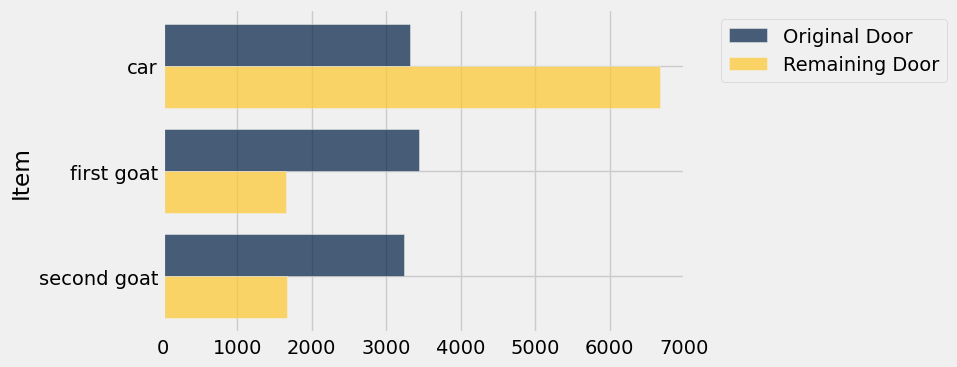

In [36]:
all_results.barh('Item')